![Programmation Python pour les mathématiques](https://python.guillod.org/fr/fig/banner.png)

**Julien Guillod**, [Sorbonne Université](http://www.sorbonne-universite.fr/), Licence [CC BY-NC-ND](https://creativecommons.org/licenses/by-nc-nd/4.0/)

L'ensemble des chapitres est disponible aux formats [HTML](https://python.guillod.org/fr/) et [PDF](https://python.guillod.org/python-fr.pdf), en français comme en anglais. Les énoncés de tous les chapitres peuvent être téléchargés au format [Jupyter notebook](https://github.com/guillod/python/tree/fr) ou exécutés directement en ligne avec [MyBinder](https://mybinder.org/v2/gh/guillod/python/fr).

Les corrigés sont disponibles dans l'ouvrage [*Programmation Python par la pratique*](https://www.dunod.com/sciences-techniques/programmation-python-par-pratique-problemes-et-exercices-corriges-0) publié chez Dunod.

<a id="ch-proba-stats"></a>

# 10. Probabilités et statistiques

Dans un premier temps, la statistique de la proportion de nombres commençant par un certain chiffre sera étudiée. Puis dans un second, des modèles probabilistes importants seront introduits et simulés, comme les marches aléatoires, des illustrations du théorème central limite ou la percolation.

**Concepts abordés**

- statistiques et probabilités
- série harmonique aléatoire
- marche aléatoire
- théorème central limite
- vecteurs aléatoires
- percolation
- transition de phase
- histogrammes
- optimisation par compilation

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Le but de cet exercice est de simuler la convergence d’une série harmonique dont le signe est tiré aléatoirement. Plus précisément si $(X_i)_{i\in\mathbb{N}}$ est une suite de variables aléatoires indépendantes valant $-1$ ou $1$ avec probabilité $\frac{1}{2}$, alors on définit la somme partielle:

$$
W_0 = 0 \,, \qquad\qquad W_n = \sum_{i=1}^n \frac{X_i}{i} \,,
$$

et la question est de déterminer si la suite $(W_n)_{n\in\mathbb{N}}$ converge et si oui vers quoi.

**a.** Écrire une fonction `sign()` qui simule la variable aléatoire $X_i$.

**b.** Écrire une fonction `simulate(n)` qui retourne une liste avec une réalisation de $(W_0,W_1,W_2,\dots,W_n)$.

**c.** Faire la représentation graphique de la fonction $n \mapsto W_n$ pour différentes réalisations par exemple pour $0\leq n\leq 1 000$ et émettre une conjecture quant à la convergence de la suite $(W_n)_{n\in\mathbb{N}}$.

**d.** <span style="color:red">!</span> Déterminer l’histogramme de $W_{1 000}$ pour $10^4$ ou $10^5$ réalisations pour avoir une idée de la loi de la variable aléatoire limite.

<a id="ex-10-02"></a>

## Exercice 10.1 - Ruine du joueur

Le but est de simuler l’évolution de la somme d’argent d’un joueur jouant à pile ou face. À chaque lancer le joueur gagne un euro si c’est pile et en perd un si c’est face. La probabilité d’obtenir pile est notée $p$, celle d’obtenir face $q$. En particulier $p=q=\frac{1}{2}$ si la pièce est équilibrée.

Mathématiquement, la somme $S_i$ possédée par le joueur au temps $i$ est donnée par une marche aléatoire:

$$S_{i}=\begin{cases}
0\,, & \text{si}\:S_{i-1}=0\,,\\
S_{i-1}+X_{i}\,, & \text{si}\:S_{i-1}\geq1\,,
\end{cases}$$

où les $(X_i)_ {i\geq1}$ sont des variables aléatoires indépendantes de loi $\mathbb{P}(X_i=1) = p$ et $\mathbb{P}(X_i=-1) = q$.

**a.** Écrire une fonction `simulate(p,k,N)` qui génère une réalisation de longueur $N$ du processus à partir de $S_0=k$, c’est-à-dire qui retourne $(S_0,S_1,S_2,\dots,S_N)$. Représenter graphiquement plusieurs réalisations.

**b.** Simuler un joueur qui, commençant avec une somme $k$, joue jusqu’à tout perdre ou avoir la somme $n \geq k$.

**c.** Si $T$ désigne le temps auquel le jeu s’arrête, *i.e.* lorsque $S_T = 0$ ou $S_T = n$, retrouver par simulation les résultats théoriques sur le temps moyen:

$$\mathbb{E}(T)=\begin{cases}
k(n-k)\,, & \text{si}\:p=q\,,\\
\dfrac{n}{p-q}\dfrac{1-\rho^{k}}{1-\rho^{n}}-\dfrac{k}{p-q}\,, & \text{si}\:p\neq q\,,
\end{cases}$$

et le lieu de sortie:

$$\mathbb{P}(S_{T}=0)=\begin{cases}
\dfrac{n-k}{n}\,, & \text{si}\:p=q\,,\\[4pt]
\dfrac{\rho^{k}-\rho^{n}}{1-\rho^{n}}\,, & \text{si}\:p\neq q\,,
\end{cases}$$

où $\rho = q/p$. Pour cela on pourra faire un graphique de ces quantités en fonction de $p$ ou se contenter de considérer le cas $p=q=\frac{1}{2}$.

<a id="ex-10-03"></a>

## Exercice 10.2 - Urnes de Polya

Une urne contient initialement (à $t=0$) $r_0$ boules rouges et $b_0$ boules blanches. À chaque instant, on tire une boule uniformément au hasard dans l’urne. On remet ensuite cette boule dans l’urne et on y ajoute une boule de la même couleur. Un tel système s’appelle une *urne de Polya*. Le but de cet exercice est d’étudier le comportement de la fraction de boules rouges dans l’urne, c’est-à-dire le nombre de boules rouges sur le nombre total. On appellera respectivement $r_n$ et $b_n$ le nombre de boules rouges et blanches présentes dans l’urne à l’instant $n$.

**a.** Écrire une fonction `densite` prenant en argument un tuple représentant le nombre de boules rouges et blanches dans une urne, et qui renvoie la densité de boules rouges.

On veut construire de manière récursive la distribution du nombre de boules rouges au temps $n$, c’est-à-dire la liste des probabilités que le nombre de boules rouges soit égal à un entier donné $k$ (qui sera l’indice de la liste). Cela se fait en écrivant deux fonctions : `next_dist_rouge`, prenant en argument la distribution à un instant $n$ et qui renvoie celle à l’instant $n+1$, qui est donc la fonction qui fait tout le travail, et `dist_rouge` qui est la fonction d’enrobage, prenant en argument $r_0$, $b_0$ et le temps $n$ et qui nous renvoie la distribution au temps $n$ par un appel récursif. On utilisera les faits utiles suivants (faire un petit dessin):

- La distribution passée en argument à `next_dist_rouge` est une liste `r` et `r[k]` représente la probabilité d’avoir `k` boules rouges dans l’urne à l’instant $n$. Les indices pour `r` varient de 0 au nombre total `s` de boules à l’instant $n$.
- Au temps $n+1$, pour avoir $k$ boules rouges, il faut:
  - soit avoir eu $k$ boules rouges à l’instant précédent et ne pas avoir tiré une boule rouge;
  - soit avoir eu $k-1$ boules rouges à l’instant précédent et avoir tiré une boule rouge.
- Si $n=0$, le résultat de `dist_rouge` est complètement déterministe et les coefficients de la liste ne sont que des 0 et 1, dépendant de $r_0$ et $b_0$.

**b.** Écrire les fonctions `next_dist_rouge` et `dist_rouge` en utilisant les indications fournies. Regarder le résultat de `dist_rouge(0,1,n)` et `dist_rouge(1,1,n)` pour différentes valeurs de `n` $(1,2,5,10,20,\dots)$ et commenter.

Plutôt que de calculer théoriquement pour chaque $n$ la suite des probabilités théoriques, nous allons faire des statistiques sur un grand nombre d’évolutions d’urnes de Polya, au bout d’un grand nombre d’étapes. Pour cela, il nous faut une fonction pour faire évoluer une urne de Polya.

**c.** Définir une fonction `polya_step(r,b)` qui, à partir de la composition d’une urne passée sous forme de deux paramètres `r` et `b`, renvoie l’évolution (aléatoire) après une étape de la composition de l’urne sous forme d’un tuple. Définir également une fonction `polya(r0,b0,N)` prenant en argument $r_0$, $b_0$ et $N$ en paramètres et renvoyant la composition (aléatoire) d’une urne de Polya au bout de $N$ étapes, aussi sous forme de tuple.

**d.** Écrire une fonction `data_rdens_polya(r0,b0,N,nbexp)` qui renvoie une liste de longueur `nbexp` contenant les densités de `nbexp` réalisations d’urnes de Polya au temps `N` initialisées avec `r0` boules rouges et `b0` boules blanches.

**e.** Stocker dans une variable le résultat de `data_rdens_polya(2,3,1000,10_000)` et dessiner un histogramme pour voir la répartition des densités. Attention, on veut que les hauteurs des barres soient normalisées pour que leur surface représente la proportion de points, et non pour qu’elles donnent le nombre de points par *bin*.

**Indication:** Une bonne règle de départ est de choisir le nombre de boîtes (*bins*) pour un histogramme de l’ordre de la racine carrée du nombre de points. Consulter la documentation de la fonction `hist` de Matplotlib.

<a id="ex-10-04"></a>

## Exercice 10.3 - Théorème central limite

Le théorème central limite (aussi appelé théorème limite central, théorème de la limite centrale ou théorème de la limite centrée) établit la convergence en loi de la somme d’une suite de variables aléatoires vers la loi normale. Intuitivement, ce résultat affirme qu’une somme de variables aléatoires identiques et indépendantes tend (sous certaines conditions) vers une variable aléatoire gaussienne. En voici une formulation:

**Théorème:** Soit $(X_n)$ une suite de variables aléatoires réelles indépendantes et de même loi admettant une espérance $\mu$ et un écart-type $\sigma \ne 0$. Soit $(\bar{X}_n)$ la suite définie par

$$
\bar{X}_n = \frac{1}{n} \sum_{k=1}^n X_k \,.
$$

Pour $n$ assez grand, la loi de $\bar{X}_n$ peut être approchée par la loi normale $\mathcal{N}(\mu, \frac{\sigma^2}{n})$.

L’objectif de cet exercice est de vérifier si ce théorème est valable pour différentes lois de probabilité :

- *Loi de Poisson*: distribution discrète sur $\mathbb{N}$, de paramètre $\lambda$, définie par :

$$
\mathbb{P}(X = k) = \exp(-\lambda) \frac{\lambda^k}{k!}\,, \quad \forall k \in \mathbb{N} \,.
$$

- *Loi normale*: distribution continue sur $\mathbb{R}$, de paramètres $m$ et $\sigma$, définie par la densité :

$$
\frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( - \frac{(x-m)^2}{2\sigma^2} \right)\,, \quad \forall x \in \mathbb{R} \,.
$$

- *Loi de Cauchy*: distribution continue sur $\mathbb{R}$, de paramètres $a$ et $\gamma$, définie par la densité :

$$
\frac{1}{\pi\gamma\left(1 + \left(\frac{x-a}{\gamma}\right)^2\right)}\,, \quad \forall x \in \mathbb{R} \,.
$$

**a.** Définir une fonction `densite_loi_normale(x, mu var)` prenant comme un argument :

- `x` (tableau) : un tableau de nombres flottants
- `mu` (nombre flottant) : moyenne $\mu$
- `var` (nombre flottant strictement positif) : variance $\sigma^2$

et qui renvoie la densité de la loi normale évaluée pour chaque nombre $x$ dans `x`:

$$
\mathcal{N}(\mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left( - \frac{(x-\mu)^2}{2\sigma^2} \right) \,.
$$

**b.** Regarder la documentation de la fonction [`numpy.random.poisson`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.poisson.html) et générer 10 valeurs aléatoires selon une loi de Poisson de paramètre $\lambda = 2$.

**c.** Écrire une fonction `echantillons_poisson(lam, N, M)` qui prend en arguments :

- `lam` (réel strictement positif): paramètre $\lambda$ pour la loi de Poisson
- `N` (entier strictement positif): nombre d’expériences
- `M` (entier strictement positif): nombre de variables aléatoires générées pour chaque expérience

et qui génère `N` expériences avec `M` variables aléatoires générées par expérience, et qui renvoie :

- la valeur moyenne (nombre flottant) sur les `N * M` variables aléatoires générées
- l’écart-type (nombre flottant) sur les `N * M` variables aléatoires générées
- un vecteur numpy de taille `N`, où chaque élément est la moyenne des variables aléatoires d’une expérience.

Pour les valeurs `lam=2` et `N=10_000`, exécuter `echantillons_poisson(lam, N, M)` pour $M \in \{10, 100, 1 000\}$ et sauvegarder les résultats dans des variables.

**d.** Pour chaque valeur de `M`, afficher la distribution du vecteur numpy contenant les moyennes de chaque expérience, ainsi que la distribution de la loi normale attendue si la théorème central limite est vérifié. On pourra utiliser la fonction `hist` de Matplotlib pour afficher l’histogramme d’un tableau, avec le paramètre `bins=50` pour fixer le nombre colonnes et `density=True` pour afficher une distribution de probabilité. On utilisera les moyennes et les écart-types empiriques renvoyés par la fonction `echantillons_poisson` pour les paramètres de la loi normale. Choisir des valeurs pertinentes pour les valeurs limites de l’axe des abscisses. Faire une hypothèse sur la validité du théorème central limite pour la loi de Poisson.

**e.** Reprendre les questions *c)* et *d)* pour la loi normale. Pour cela, utiliser la fonction [`numpy.random.normal`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.normal.html) puis générer des moyennes avec les paramètres `loc=2`, `scale=1`, `N=10_000` et $M \in \{10, 100, 1 000\}$. Tracer les histogrammes et faire une hypothèse sur la validité du théorème central limite pour la loi normale.

**f.** Reprendre les questions *c)* et *d)* pour la loi de Cauchy avec $a=0$ et $\gamma=1$. Pour cela utiliser la fonction [`numpy.random.standard_cauchy`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.standard_cauchy.html). Utiliser `bins=np.arange(-10, 10.1, 0.1)` et faire une hypothèse sur la validité du théorème central limite pour la loi de Cauchy.

<a id="ex-10-05"></a>

## Exercice 10.4 - Génération aléatoire de vecteurs unitaires

L’objectif de cet exercice est de trouver une méthode efficace pour générer aléatoirement des vecteurs unitaires dans $\mathbb{R}^n$ selon une loi uniforme. Nous allons commencer par le cas $n = 2$, où l’on peut représenter un vecteur réel par un nombre complexe.

**a.** On considère la stratégie suivante pour générer aléatoirement un vecteur unitaire dans $\mathbb{R}^2$ :

1.  Générer $x$ aléatoirement selon la loi uniforme sur $[-1, 1]$.

<!-- -->

1.  Générer $y$ aléatoirement selon la loi uniforme sur $[-1, 1]$.

<!-- -->

1.  Renvoyer le complexe unitaire $z = \frac{x}{\sqrt{x^2 + y^2}} + \frac{y}{\sqrt{x^2 + y^2}}i$.

Écrire une fonction `generer_complexe` qui prend en argument un entier positif $N$ et qui renvoie un tableau NumPy de taille $N$, où chaque élément est un complexe généré par la stratégie ci-dessus.

**Indication:** Il est beaucoup plus efficace de générer directement $N$ variables aléatoires en utilisant l’argument `size` de la fonction [`numpy.random.uniform`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.uniform.html) que de les générer une par une avec une boucle `for`.

**b.** Pour $n=2$, une manière de vérifier si la distribution des vecteurs est uniforme est de regarder la distribution des angles/arguments des nombres complexes (c’est-à-dire $\arg{z}$) : celle-ci doit être uniforme. Utiliser la fonction `generer_complexe` avec $N = 10^6$ et afficher la distribution des angles/arguments. La stratégie présentée à la question précédente permet-elle de générer des vecteurs unitaires de manière uniforme ?

**Indication:** On pourra utiliser la fonction [`numpy.angle`](https://numpy.org/doc/stable/reference/generated/numpy.angle.html).

**c.** On propose cette modification à la stratégie précédente :

1.  Générer $x$ aléatoirement selon la loi uniforme sur $[-1, 1]$.

<!-- -->

1.  Générer $y$ aléatoirement selon la loi uniforme sur $[-1, 1]$.

<!-- -->

1.  Si $x^2 + y^2 \leq 1$, renvoyer le complexe unitaire $z = \frac{x}{\sqrt{x^2 + y^2}} + \frac{y}{\sqrt{x^2 + y^2}}i$ (sinon ne rien renvoyer du tout).

Écrire une fonction `generer_complexe_monte_carlo` qui prend en argument un entier positif $N$, correspondant au nombre de vecteurs candidats et qui renvoie un tableau NumPy de taille $n \leq N$, où chaque élément est un complexe généré par la stratégie ci-dessus. *Attention :* $n$ est aléatoire et ne peut donc pas être déterminé à l’avance.

Reprendre la question précédente et afficher la distribution des angles/arguments des complexes générés par cette stratégie. Cette stratégie permet-elle de générer des vecteurs unitaires de manière uniforme ?

**d.** On se demande maintenant combien de complexes candidats il faut générer en moyenne pour en accepter $n$, ce qui est équivalent à déterminer combien de complexes sont en moyenne acceptés parmi les $N$ candidats. La loi des grands nombres permet d’affirmer que le ratio converge vers la probabilité qu’un vecteur candidat soit accepté. Cette probabilité est égale au ratio de la surface d’inclusion $\pi$ (le cercle unitaire) sur la surface totale $4$ (le carré $[-1, 1]^2$), c’est-à-dire $\frac{\pi}{4}$. Comparer le ratio $\frac{n}{N}$ à $\frac{\pi}{4}$.

**e.** On se place maintenant dans le cas général $n \geq 2$. La stratégie considérée est la même que celle à la question *c)* :

1.  Générer un vecteur $\boldsymbol{x}=(x_1, \ldots, x_n)$ où chaque $x_k$ est généré aléatoirement et de manière indépendante selon la loi uniforme sur $[-1, 1]$.

<!-- -->

1.  Si $\Vert \boldsymbol{x} \Vert_2 \leq 1$, renvoyer le vecteur unitaire $\frac{\boldsymbol{x}}{\Vert \boldsymbol{x} \Vert_2}$.

Le volume de la boule unitaire dans $\mathbb{R}^n$ est donné par :

$$
V_n = \frac{\pi^{n/2}}{\Gamma(\frac{n}{2} + 1)}
$$

et le volume du cube $[-1, 1]^n$ est $2^n$. Afficher sur un graphique la probabilité qu’un vecteur soit accepté à l’étape 2 de cette stratégie pour $n \in \{2, \ldots, 20\}$. Pensez-vous que cette stratégie est efficace pour de grandes valeurs de $n$ ?

**Indication:** On pourra utiliser [`scipy.special.gamma`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.gamma.html) pour la fonction $\Gamma$ et la fonction [`scatter`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) de Matplotlib pour afficher graphiquement les valeurs d’une suite avec une [échelle](https://matplotlib.org/stable/gallery/scales/scales.html) adaptée.

**f.** Il est possible de montrer que la stratégie suivante permet de générer des vecteurs aléatoires sur $\mathbb{R}^n$ :

1.  Générer un vecteur $\boldsymbol{x}=(x_1, \ldots, x_n)$ où chaque $x_k$ est généré aléatoirement et de manière indépendante selon la loi normale centrée réduite : $x_k \sim \mathcal{N}(0, 1)$.
2.  Renvoyer le vecteur unitaire $\frac{\boldsymbol{x}}{\Vert \boldsymbol{x} \Vert_2}$.

Vérifier pour $n=2$ que cette stratégie génère bien aléatoirement des vecteurs unitaires selon une loi uniforme en affichant la distribution des angles (en représentant les vecteurs comme des nombres complexes) pour $N = 10^6$ vecteurs.

**Indication:** On pourra utiliser la fonction [`numpy.random.standard_normal`](https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.standard_normal.html).

<a id="ex-10-06"></a>

## Exercice 10.5 - Percolation <span style="color:red">!!</span>

Le but est d’étudier un modèle de percolation dans un milieu poreux. Le milieu est modélisé par une matrice aléatoire de booléens qui détermine les sites qui peuvent être envahis par l’eau et ceux qui sont imperméables. Une matrice percole s’il existe un chemin d’eau allant de la ligne supérieure vers la ligne inférieure. Dans les exemples de la <a href="#fig-percolation-def" class="quarto-xref">Figure 10.1</a>, les entrées d’une matrice pouvant être envahies par l’eau sont colorées et les entrées effectivement remplies d’eau sont en bleu. La première matrice ne percole pas alors que la seconde oui.

<a id="fig-percolation-def"></a>

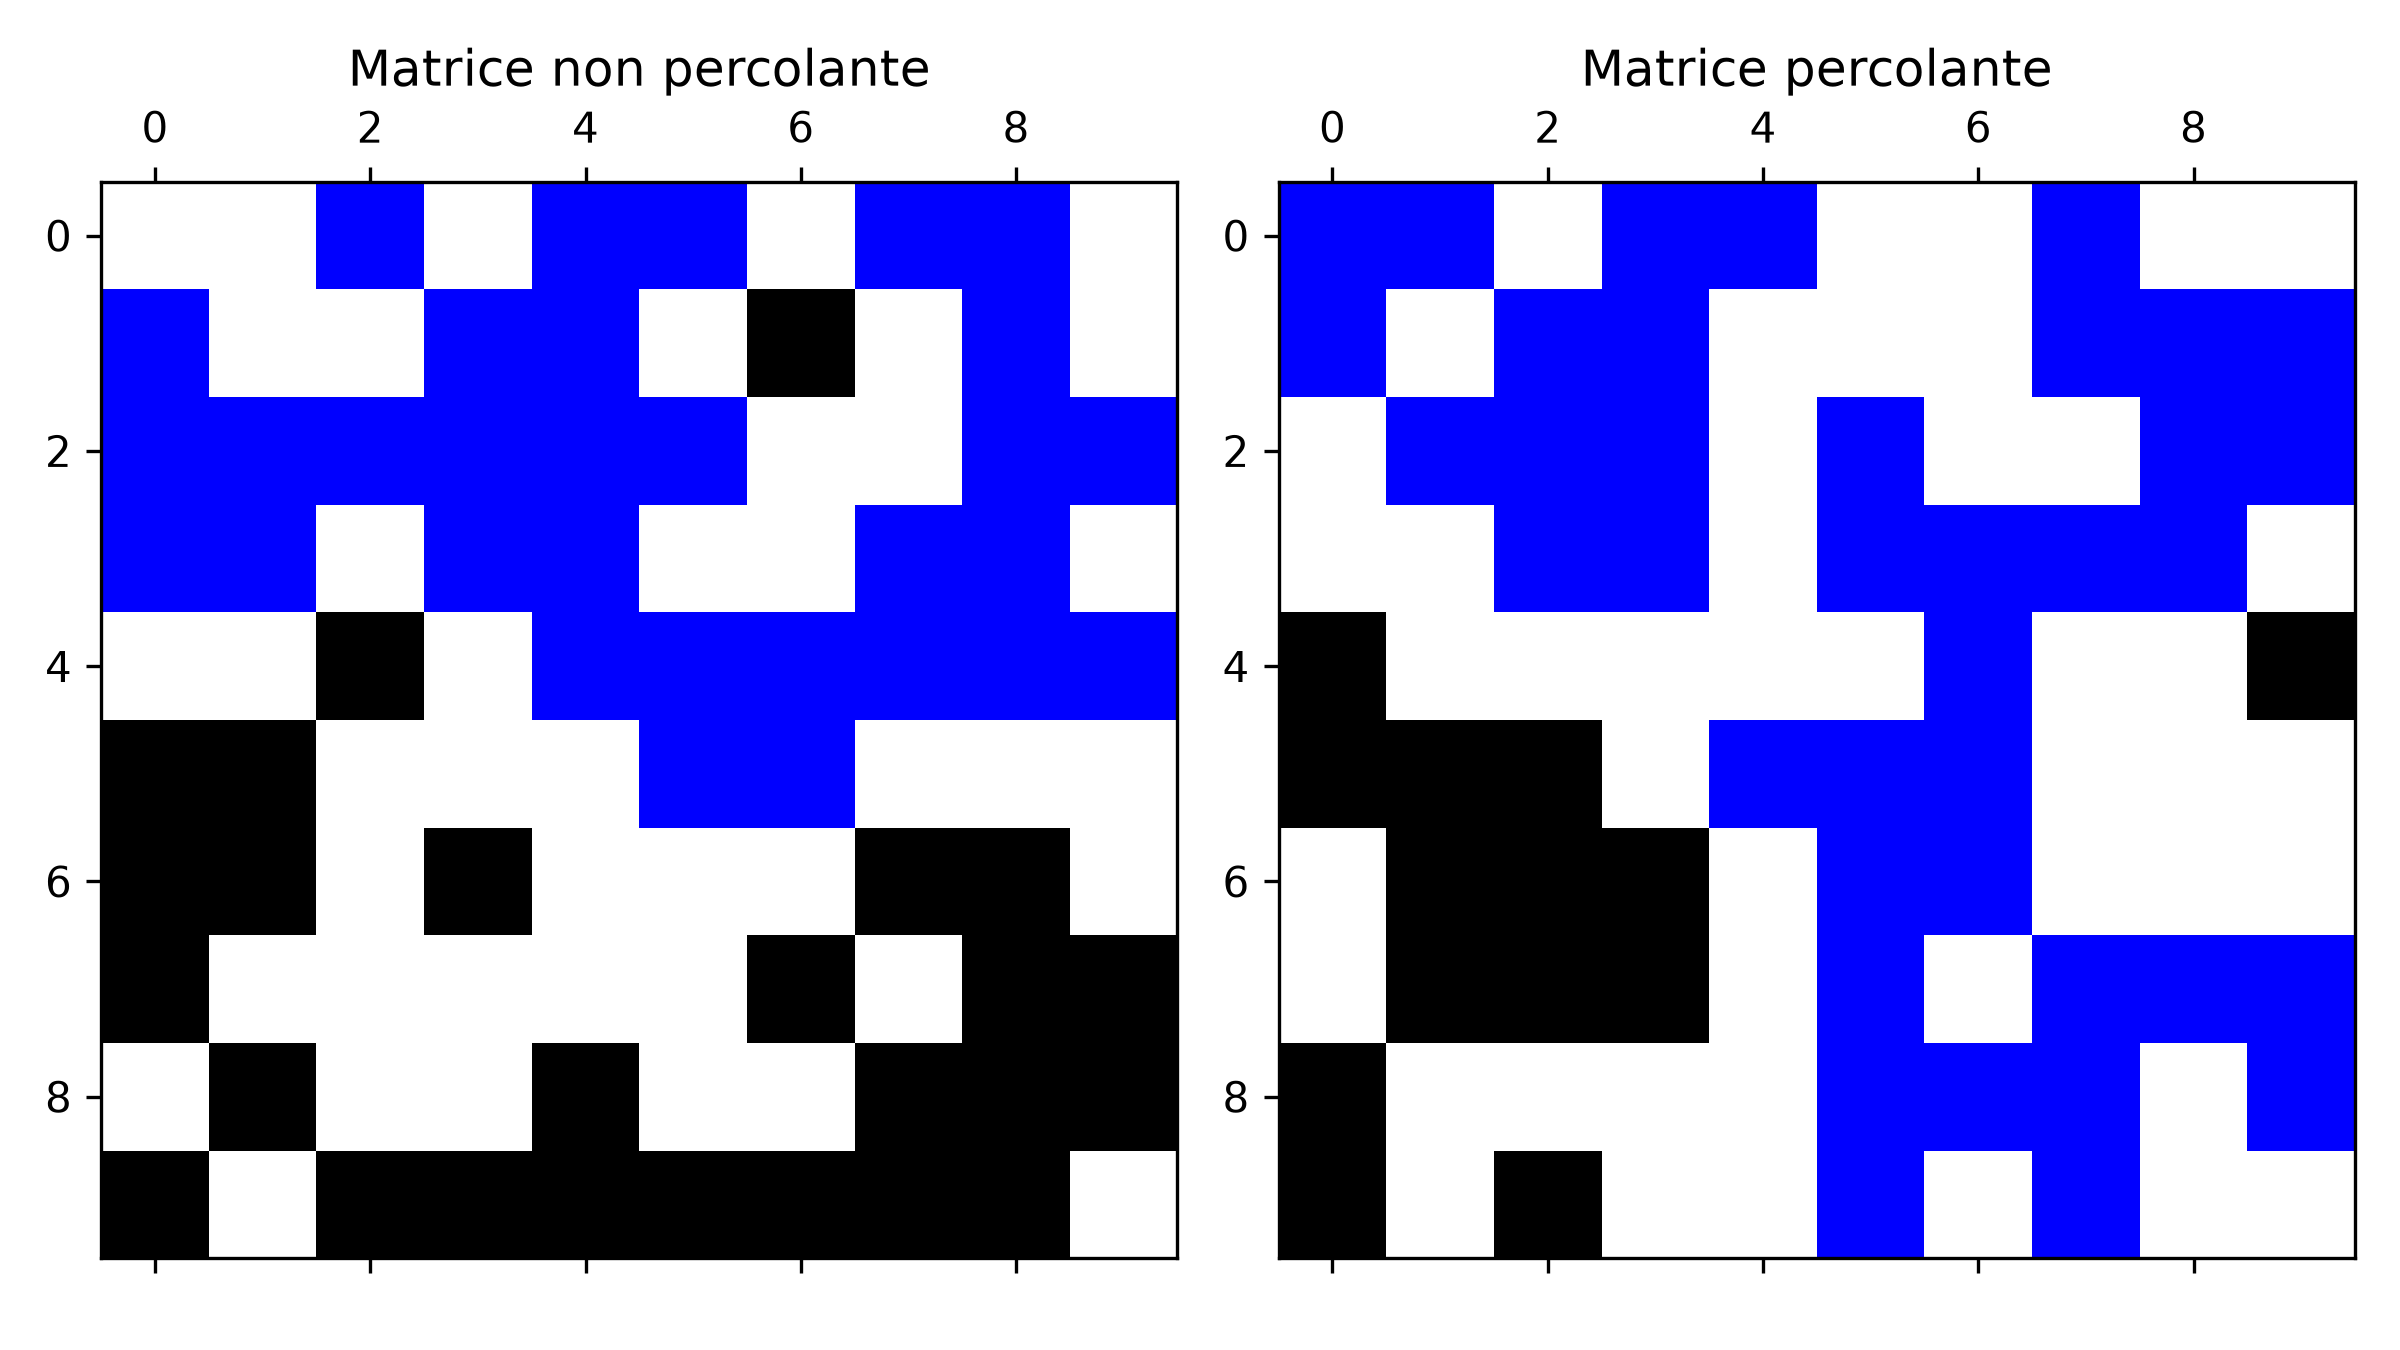

Figure 10.1: La matrice de gauche ne percole pas alors que celle de droite oui.

**a.** Écrire une fonction `generate(n,p)` qui génère une matrice de booléens de taille $n \times n$ telle que chaque entrée ait une probabilité $p$ d’être juste et $1-p$ d’être fausse.

**Indication:** La fonction `random.binomial` de NumPy peut être utile.

**b.** Définir une fonction `fill(isopen)` qui pour une matrice de booléens donnée renvoie une autre matrice de booléens avec les entrées envahies par l’eau.

**Indication:** Définir une matrice de booléens `isfull` pour stocker si une entrée est remplie par l’eau ou pas, puis définir une fonction récursive `flow(isopen, isfull, i, j)` permettant d’envahir toutes les entrées possibles à partir de $(i,j)$.

**c.** À l’aide de Matplotlib représenter le remplissage de différentes matrices générées aléatoirement.

**d.** Définir une fonction `percolate(isopen)` permettant de déterminer si une matrice de booléens percole ou non.

**e.** <span style="color:red">!!</span> Calculer le temps nécessaire pour déterminer si une matrice de taille $50 \times 50$ avec $p=0.9$ percole ou non. Lire la documentation du module Numba pour réduire le temps de calcul en compilant une des fonctions: <https://numba.pydata.org/>.

**Indication:** La fonction qui est la plus utilisée est la fonction récursive, donc c’est celle qu’il faut optimiser en la compilant.

**f.** En faisant des statistiques, déterminer la probabilité qu’une matrice aléatoire booléenne de taille $n \times n$ avec probabilité $p$ percole. Étudier cette probabilité en fonction de $p$ et de $n$.

**Indication:** Faire le graphique de cette probabilité de percolation en fonction de $p$ pour différentes valeurs de $n$.

**g.** <span style="color:red">!!!</span> Les statistiques effectuées au point précédent sont un exemple typique de calculs pouvant être facilement exécutés en parallèle, car chaque cas est indépendant des autres. Paralléliser l’algorithme précédent de manière à utiliser tous les cœurs de son processeur, par exemple à l’aide du module [`mpi4py`](https://mpi4py.readthedocs.io/).

**Indication:** L’utilisation de Jupyter Lab pour faire du calcul parallèle est assez complexe à mettre en œuvre, il vaut mieux utiliser la ligne de commande pour exécuter un script en parallèle, par exemple pour quatre cœurs: `mpirun -n 4 script.py`. À noter que [Open MPI](https://www.open-mpi.org/) ou [MPICH](https://www.mpich.org/) doit être installé sur l’ordinateur.